# K ближайших соседей (K-Nearest Neighbors, KNN)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**K ближайших соседей** (сокращённо **KNN** — от англ. *K-Nearest Neighbors*, «K ближайших соседей») — это простой и наглядный алгоритм машинного обучения. Идея очень простая: чтобы предсказать класс нового объекта, алгоритм ищет среди обучающей выборки **K** самых похожих на него объектов (то есть тех, которые находятся ближе всего по заданной метрике расстояния — чаще всего это евклидово расстояние, то есть обычное «расстояние по прямой»), и выбирает тот класс, который встречается среди этих соседей чаще всего. KNN относится к так называемым **ленивым** методам (*lazy learning*): модель, по сути, ничего не «учит» заранее — она просто запоминает обучающую выборку, а все вычисления делает в момент предсказания. Метод легко объяснить, он не требует сложной настройки, но очень чувствителен к масштабу признаков (поэтому перед обучением признаки обычно приводят к одному масштабу — стандартизируют) и к выбору числа соседей **K**.


## 2. Блок с используемыми библиотеками


In [1]:
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

sns.set(style="whitegrid")
np.random.seed(42)

**Пояснения терминов (что означают англоязычные названия):**

- **scikit-learn** (читается «сайкит-лёрн») — библиотека машинного обучения на языке Python.
- **StandardScaler** — стандартизатор: приводит признаки к «одному масштабу» (среднее 0, разброс 1). Для KNN это особенно важно, потому что метод опирается на расстояния между объектами.
- **Pipeline** (конвейер) — «цепочка шагов» обработки: сначала масштабирование, потом модель. Удобно, чтобы одни и те же шаги применялись одинаково и на обучении, и на тесте.
- **GridSearchCV** — перебор параметров модели по сетке значений с проверкой на кросс-валидации (кросс-проверке). Выбирает ту комбинацию, где качество оказалось лучшим.
- **train / test** — обучающая и тестовая выборки. Обучающую используем, чтобы модель «училась», а тестовую — чтобы честно проверить, как она работает на новых данных.
- **permutation importance** (важность через перемешивание) — способ оценить, насколько признак важен для модели: признак случайно перемешивают и смотрят, сильно ли упало качество.


## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера используем встроенный набор данных **Wine** (в переводе — «Вино») из библиотеки scikit-learn. Задача — по 13 числовым химическим показателям (содержание алкоголя, кислот, магния, цвет и т.д.) определить один из трёх сортов винограда, то есть задача **многоклассовой классификации**. Датасет встроенный (ничего скачивать не нужно), поэтому ноутбук сразу запускается в Google Colab.


In [2]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
target_names = data.target_names  # ['class_0', 'class_1', 'class_2'] — три сорта

df = X.copy()
df["target"] = y

print("Размерность X (строк, признаков):", X.shape)
print("\nНазвания признаков:")
print(list(X.columns))

print("\nРаспределение классов (0/1/2):")
print(y.value_counts().sort_index())

print("\nПервые 5 строк датасета:")
display(df.head(5))

print("\nКраткая информация о таблице:")
display(df.info())

print("\nОписательная статистика (первые 10 признаков):")
display(df.describe().T.head(10))


Размерность X (строк, признаков): (178, 13)

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Распределение классов (0/1/2):
target
0    59
1    71
2    48
Name: count, dtype: int64

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Краткая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178

None


Описательная статистика (первые 10 признаков):


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 4. Блок с предварительной обработкой датасета

Для метода K ближайших соседей масштабирование признаков **обязательно**: если один признак измеряется в сотнях, а другой — в единицах, то расстояние «перекосится» в сторону крупного признака. Поэтому далее в конвейере (Pipeline) добавлен шаг `StandardScaler`. Также проверим пропуски и дубликаты и разобьём данные на обучающую и тестовую части.


In [3]:
# 1) Пропуски по столбцам
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски (топ-10 признаков):")
print(missing.head(10))

# 2) Дубликаты строк
dup_count = df.duplicated().sum()
print("\nКоличество дубликатов строк:", dup_count)

# 3) Разделение на признаки X и цель y
X = df.drop(columns=["target"])
y = df["target"]

# 4) Разделение на обучающую и тестовую выборки.
#    stratify=y — сохраняем доли классов (чтобы в обеих частях классы были в нужных пропорциях).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nРазмеры выборок:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nДоли классов в обучающей части:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nДоли классов в тестовой части:")
print(y_test.value_counts(normalize=True).sort_index())


Пропуски (топ-10 признаков):
alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
dtype: int64

Количество дубликатов строк: 0

Размеры выборок:
X_train: (142, 13) | X_test: (36, 13)

Доли классов в обучающей части:
target
0    0.330986
1    0.401408
2    0.267606
Name: proportion, dtype: float64

Доли классов в тестовой части:
target
0    0.333333
1    0.388889
2    0.277778
Name: proportion, dtype: float64


## 5. Блок с тепловой картой

Тепловая карта (англ. *heatmap*) показывает **корреляции** — насколько сильно признаки связаны друг с другом и с целевой переменной. Значения близкие к **+1** означают сильную прямую связь, близкие к **−1** — сильную обратную связь, а близкие к **0** — связи практически нет.


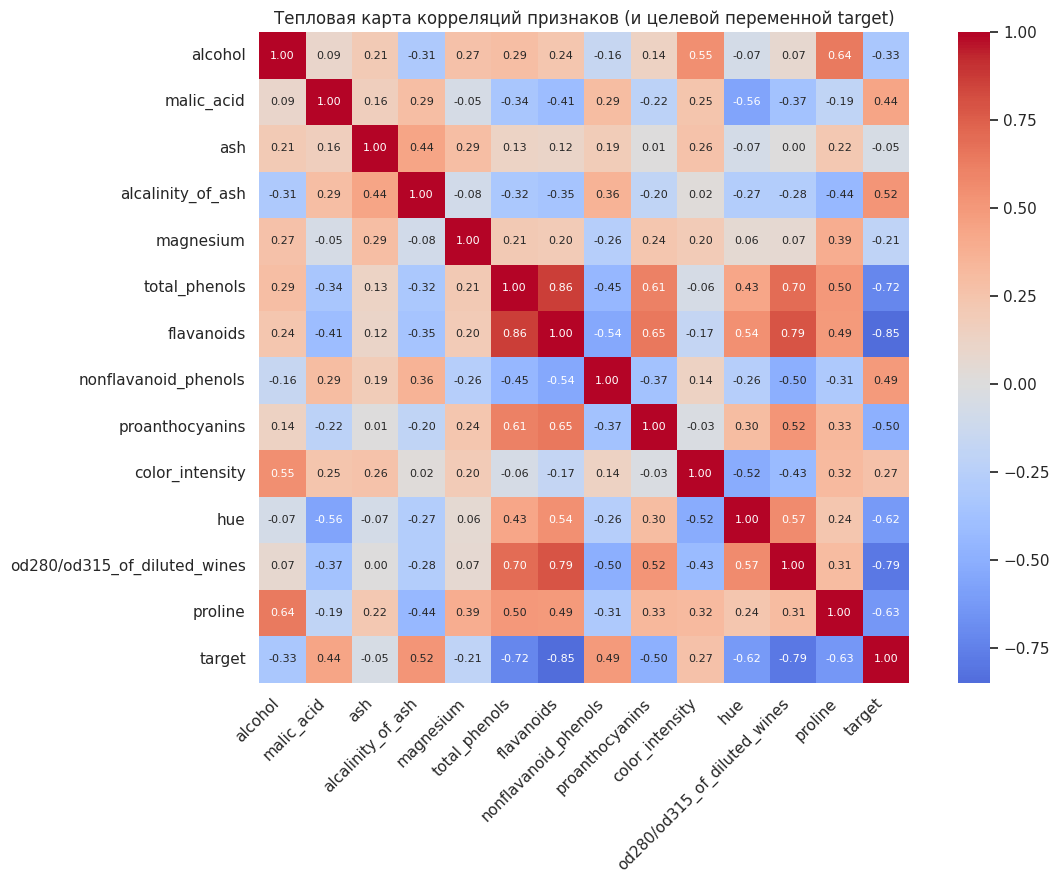

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Тепловая карта корреляций признаков (и целевой переменной target)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Блок с обучением модели

Собираем конвейер (Pipeline): сначала `StandardScaler` (масштабирование признаков), затем `KNeighborsClassifier` (сам классификатор K ближайших соседей). Подбор оптимальных параметров выполняем через **GridSearchCV** — перебор по сетке значений с кросс-валидацией (кросс-проверкой) на 5 частях.

Перебираем:
- **n_neighbors** — число соседей *K*;
- **weights** — как взвешивать соседей: все одинаково (`uniform`) или ближние важнее (`distance`);
- **p** — тип расстояния: `1` — манхэттенское («по сетке улиц»), `2` — евклидово («по прямой»).


In [5]:
# Конвейер: масштабирование -> KNN
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Сетка параметров. Префикс 'knn__' означает, что параметр относится к шагу 'knn' конвейера.
param_grid = {
    "knn__n_neighbors": list(range(1, 21)),   # K от 1 до 20
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],                          # 1 = manhattan, 2 = euclidean
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_knn = grid.best_estimator_

print("Лучшие параметры KNN:")
print(grid.best_params_)
print("\nЛучшая точность на кросс-валидации (cv=5):", round(grid.best_score_, 4))


Лучшие параметры KNN:
{'knn__n_neighbors': 8, 'knn__p': 1, 'knn__weights': 'uniform'}

Лучшая точность на кросс-валидации (cv=5): 0.9862


## 7. Блок с прогнозами модели

Делаем прогнозы обученной моделью на тестовой выборке и считаем:
- **accuracy** (точность) — доля правильных предсказаний;
- **classification_report** — отчёт с precision / recall / F1 по каждому классу;
- **confusion_matrix** — матрицу ошибок (кто с кем перепутался).


In [6]:
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)  # оценки вероятностей классов

acc = accuracy_score(y_test, y_pred)
print("Точность (accuracy) на тестовой выборке:", round(acc, 4))

print("\nОтчёт по классификации (precision / recall / F1 по каждому классу):")
print(classification_report(
    y_test, y_pred,
    target_names=[str(t) for t in target_names]
))

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок (confusion matrix):")
print(cm)

# Примеры прогнозов — покажем истинный класс, предсказанный и вероятности
preview = pd.DataFrame({
    "Истинный класс": y_test.values,
    "Прогноз модели": y_pred,
    "Вероятность класса 0": y_proba[:, 0].round(3),
    "Вероятность класса 1": y_proba[:, 1].round(3),
    "Вероятность класса 2": y_proba[:, 2].round(3),
})
print("\nПримеры прогнозов (первые 12 строк тестовой выборки):")
display(preview.head(12))


Точность (accuracy) на тестовой выборке: 1.0

Отчёт по классификации (precision / recall / F1 по каждому классу):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Матрица ошибок (confusion matrix):
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

Примеры прогнозов (первые 12 строк тестовой выборки):


,Истинный класс,Прогноз модели,Вероятность класса 0,Вероятность класса 1,Вероятность класса 2
0,0,0,1.000,0.000,0.000
1,2,2,0.000,0.250,0.750
2,0,0,1.000,0.000,0.000
3,1,1,0.375,0.625,0.000
4,1,1,0.125,0.875,0.000
5,0,0,1.000,0.000,0.000
6,0,0,1.000,0.000,0.000
7,1,1,0.375,0.625,0.000
8,1,1,0.000,1.000,0.000
9,2,2,0.000,0.000,1.000


## 8. Блок с графиками выходных результатов

Графики:
1. **Зависимость качества от числа соседей K** — помогает понять, какое K оптимально и где начинается переобучение / недообучение.
2. **Матрица ошибок** в виде тепловой карты — удобно смотреть, какие классы модель путает чаще всего.
3. **Важность признаков** через *permutation importance* (важность через перемешивание) — у KNN нет встроенного `feature_importances_`, поэтому используем универсальный способ: перемешиваем значения признака и смотрим, насколько упало качество.
4. **Двумерная визуализация границ классов** — показываем, как KNN разделяет пространство, используя два самых важных признака (остальные усредняются).


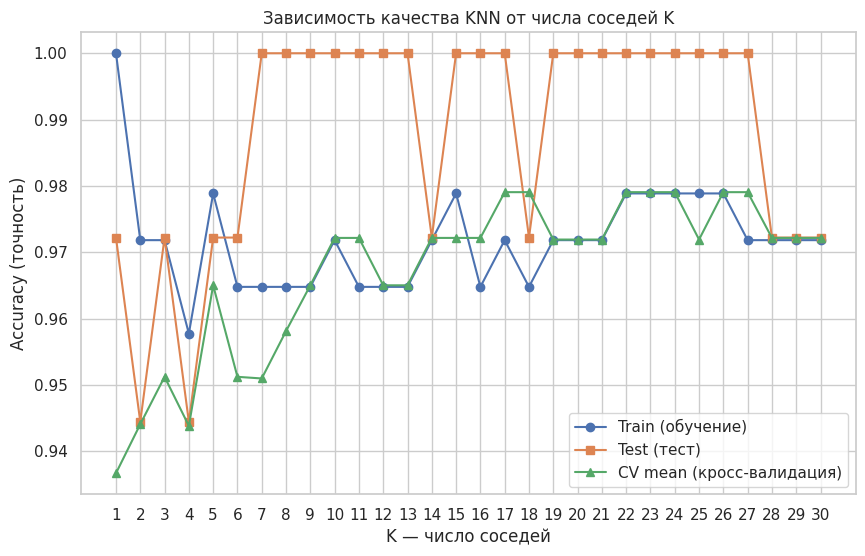

In [7]:
# --- 8.1 Зависимость качества (accuracy) от числа соседей K ---
# Для каждого K обучаем конвейер (со стандартизацией) и меряем качество:
#  - на обучении (train)
#  - на тесте (test)
#  - по кросс-валидации (среднее по 5 частям)

k_values = list(range(1, 31))
train_scores, test_scores, cv_scores = [], [], []

for k in k_values:
    pipe_k = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_k.fit(X_train, y_train)

    train_scores.append(accuracy_score(y_train, pipe_k.predict(X_train)))
    test_scores.append(accuracy_score(y_test, pipe_k.predict(X_test)))

    cv_mean = cross_val_score(pipe_k, X_train, y_train, cv=5, scoring="accuracy").mean()
    cv_scores.append(cv_mean)

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker="o", label="Train (обучение)")
plt.plot(k_values, test_scores, marker="s", label="Test (тест)")
plt.plot(k_values, cv_scores, marker="^", label="CV mean (кросс-валидация)")
plt.xlabel("K — число соседей")
plt.ylabel("Accuracy (точность)")
plt.title("Зависимость качества KNN от числа соседей K")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()


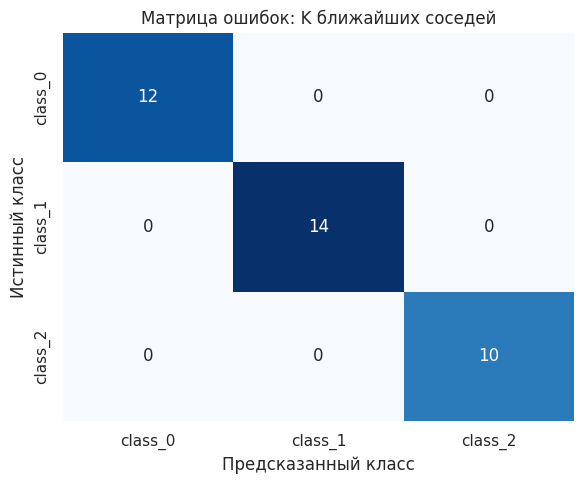

In [8]:
# --- 8.2 Матрица ошибок в виде тепловой карты ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=[str(t) for t in target_names],
    yticklabels=[str(t) for t in target_names]
)
plt.title("Матрица ошибок: K ближайших соседей")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()


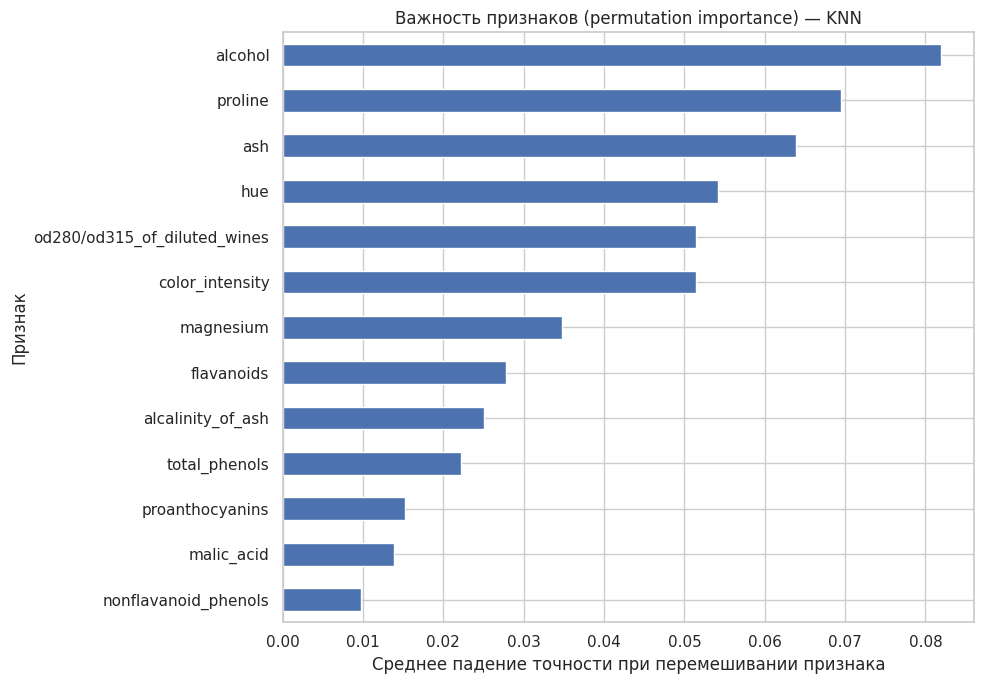

Топ-5 самых важных признаков:


,важность
alcohol,0.081944
proline,0.069444
ash,0.063889
hue,0.054167
od280/od315_of_diluted_wines,0.051389


In [9]:
# --- 8.3 Важность признаков через permutation importance ---
# У KNN нет встроенной важности признаков, поэтому считаем её так:
# перемешиваем значения одного признака и смотрим, насколько упала точность.
# Чем сильнее упала — тем признак важнее.

perm = permutation_importance(
    best_knn, X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(perm.importances_mean, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances_sorted.plot(kind="barh")
plt.title("Важность признаков (permutation importance) — KNN")
plt.xlabel("Среднее падение точности при перемешивании признака")
plt.ylabel("Признак")
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()

print("Топ-5 самых важных признаков:")
display(importances.sort_values(ascending=False).head(5).to_frame("важность"))


Два самых важных признака: ['alcohol', 'proline']


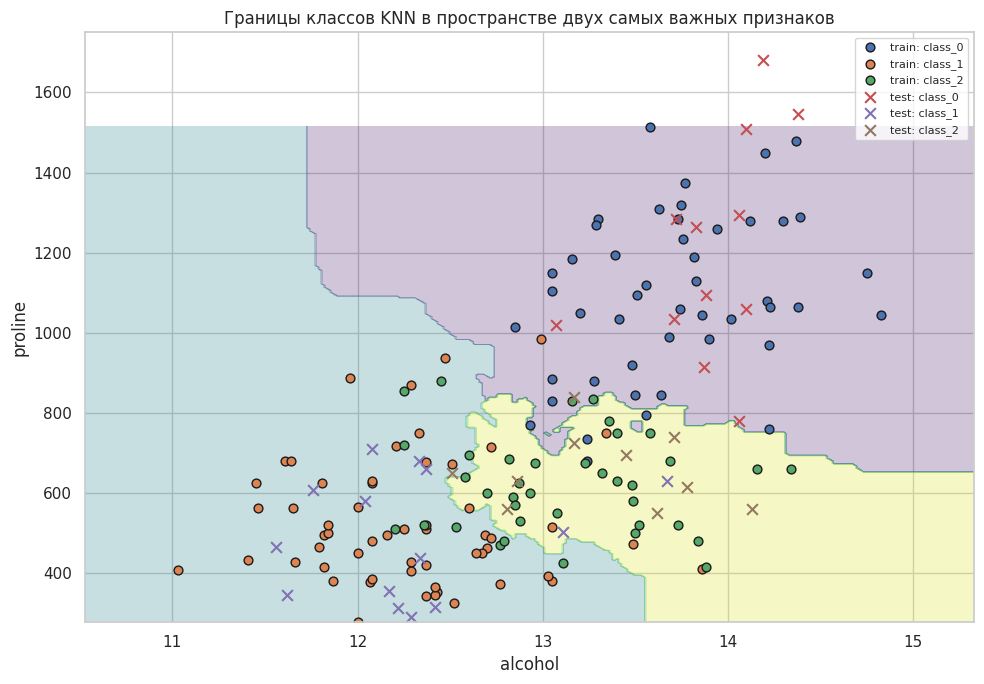

In [10]:
# --- 8.4 Двумерная визуализация границ классов ---
# Берём два самых важных признака (по permutation importance) и обучаем KNN только на них,
# чтобы можно было нарисовать 2D-график с областями, где модель предсказывает каждый класс.

top2 = importances.sort_values(ascending=False).head(2).index.tolist()
print("Два самых важных признака:", top2)

X_train_2d = X_train[top2].values
X_test_2d = X_test[top2].values

# Используем те же лучшие параметры, что нашёл GridSearchCV
best_params = {k.replace("knn__", ""): v for k, v in grid.best_params_.items()}

pipe_2d = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(**best_params))
])
pipe_2d.fit(X_train_2d, y_train)

# Делаем сетку точек, чтобы нарисовать, какой класс модель предсказывает в каждой точке плоскости
pad = 0.5
x_min = X_train_2d[:, 0].min() - pad
x_max = X_train_2d[:, 0].max() + pad
y_min = X_train_2d[:, 1].min() - pad
y_max = X_train_2d[:, 1].max() + pad

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = pipe_2d.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")

for cls, name in zip(np.unique(y_train), target_names):
    mask = y_train.values == cls
    plt.scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1],
        label=f"train: {name}",
        edgecolor="k",
        s=40
    )

for cls, name in zip(np.unique(y_test), target_names):
    mask = y_test.values == cls
    plt.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        label=f"test: {name}",
        marker="x",
        s=60
    )

plt.title(f"Границы классов KNN в пространстве двух самых важных признаков")
plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


---

### Короткий вывод

Метод **K ближайших соседей (KNN)** показал хорошее качество на датасете Wine. Подбор параметров через `GridSearchCV` определил оптимальное число соседей **K**, тип расстояния и способ взвешивания соседей. Графики показывают, как точность зависит от **K**, какие классы путаются, какие признаки вносят наибольший вклад в решение и как выглядят границы классов в пространстве двух ключевых признаков. Ключевая особенность KNN: метод напрямую опирается на расстояния между объектами, поэтому стандартизация признаков (`StandardScaler`) — обязательный шаг.
